# DDSM-ACGAN — benign vs malignant mammography augmentation on Colab

Applies the same ACGAN + VGG16 architecture from the CovidGAN reconstruction to **CBIS-DDSM mammography ROI patches**, classifying **benign vs malignant** rather than COVID vs Normal. Same pipeline shape: train an ACGAN on real ROIs → generate a synthetic pool → train the detection CNN with and without synthetic augmentation → compare.

**Before running:** `Runtime > Change runtime type > T4 GPU`. This notebook expects:
- A zipped folder of pre-extracted CBIS-DDSM ROI patches on your Drive, named like `P_<patient>_<LEFT|RIGHT>_<CC|MLO>_<mass|calcification>_<n>.png`.
- The four standard CBIS-DDSM case-description CSVs (mass/calc × train/test) on your Drive.

Repo: https://github.com/MayaHayat/generative_models — this notebook lives in `DDSM-ACGAN-Pytorch/`.

In [1]:
!nvidia-smi

Wed Jul 29 06:16:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Drive, clone the repo, install light dependencies

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/MayaHayat/generative_models.git
%cd generative_models/DDSM-ACGAN-Pytorch
!pip install -q scikit-learn matplotlib pillow

Cloning into 'generative_models'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 36 (delta 8), reused 35 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 7.85 MiB | 11.52 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/generative_models/DDSM-ACGAN-Pytorch


## 2. Unzip the ROI patches

Adjust the path to wherever your `ddsm_rois.zip` actually lives on Drive.

In [4]:
ROI_ZIP = '/content/drive/MyDrive/Thesis/ddsm_rois.zip'
!unzip -q "{ROI_ZIP}" -d /content/ddsm_rois
!find /content/ddsm_rois -maxdepth 3 -type d

/content/ddsm_rois
/content/ddsm_rois/rois


The unzip usually produces a top-level folder (e.g. `/content/ddsm_rois/rois`) containing the PNG files directly. If the listing above shows a different nesting, update `ROI_DIR` in the next cell to match.

In [5]:
ROI_DIR = '/content/ddsm_rois/rois'
!ls {ROI_DIR} | head -5
!ls {ROI_DIR} | wc -l

P_00001_LEFT_CC_mass_1.png
P_00001_LEFT_MLO_mass_1.png
P_00004_LEFT_CC_mass_1.png
P_00004_LEFT_MLO_mass_1.png
P_00004_RIGHT_MLO_mass_1.png
3568


## 3. Point at the CBIS-DDSM metadata CSVs

These carry the benign/malignant pathology labels and the official train/test split — adjust the folder if yours differs.

In [6]:
CSV_DIR = '/content/drive/MyDrive/Thesis/tabular-dataset'
MASS_TRAIN_CSV = f'{CSV_DIR}/mass_case_description_train_set.csv'
MASS_TEST_CSV  = f'{CSV_DIR}/mass_case_description_test_set.csv'
CALC_TRAIN_CSV = f'{CSV_DIR}/calc_case_description_train_set.csv'
CALC_TEST_CSV  = f'{CSV_DIR}/calc_case_description_test_set.csv'

## 4. Build the manifest (join ROIs to pathology labels)

**Read the match-rate report this prints carefully.** If it's low, the CSV column names or ROI filenames don't match what this script assumes — check the printed sample of unmatched files before trusting anything downstream.

In [7]:
!python prepare_ddsm.py --roi-dir {ROI_DIR} --mass-train-csv {MASS_TRAIN_CSV} --mass-test-csv {MASS_TEST_CSV} --calc-train-csv {CALC_TRAIN_CSV} --calc-test-csv {CALC_TEST_CSV} --out-dir data

Matched 3568/3568 ROI files to a pathology label (100.0%).

Matched breakdown:
  train  benign     1683
  train  malignant  1181
  test   benign     428
  test   malignant  276

Wrote data/manifest.csv


## 5. Train the ACGAN — generator + discriminator

`GAN_EPOCHS = 2000` mirrors CovidGAN's setting. Start with something like 50 to sanity-check the whole pipeline before committing hours to it — and note how much smaller/larger your train set is than CovidGAN's 932 images, which changes how long each epoch actually takes.

In [8]:
GAN_EPOCHS = 500  # try e.g. 50 for a quick smoke test first

!python train_gan.py --manifest data/manifest.csv --out-dir runs/gan --epochs {GAN_EPOCHS} --batch-size 64 --lr 2e-4 --beta1 0.5 --sample-every 25 --checkpoint-every 100

device: cuda
training images: 2864
G params: 22,247,542  D params: 1,644,832
epoch 1/500  D_loss=1.7061  G_loss=3.1311
epoch 2/500  D_loss=1.2977  G_loss=5.2505
epoch 3/500  D_loss=1.2519  G_loss=4.9045
epoch 4/500  D_loss=1.1928  G_loss=5.2393
epoch 5/500  D_loss=1.1654  G_loss=5.2721
epoch 6/500  D_loss=1.5225  G_loss=4.2458
epoch 7/500  D_loss=1.9000  G_loss=2.1824
epoch 8/500  D_loss=1.6004  G_loss=2.6763
epoch 9/500  D_loss=1.6098  G_loss=3.4013
epoch 10/500  D_loss=1.6460  G_loss=4.5972
epoch 11/500  D_loss=1.5141  G_loss=4.0054
epoch 12/500  D_loss=1.5203  G_loss=3.2451
epoch 13/500  D_loss=1.4680  G_loss=4.0434
epoch 14/500  D_loss=2.0805  G_loss=4.0696
epoch 15/500  D_loss=1.3509  G_loss=5.2815
epoch 16/500  D_loss=1.7097  G_loss=3.7083
epoch 17/500  D_loss=1.6871  G_loss=2.9143
epoch 18/500  D_loss=1.3510  G_loss=3.8037
epoch 19/500  D_loss=1.2394  G_loss=4.3955
epoch 20/500  D_loss=1.3619  G_loss=4.0318
epoch 21/500  D_loss=1.2993  G_loss=3.9571
epoch 22/500  D_loss=1.4992  

Preview the most recent sample grid:

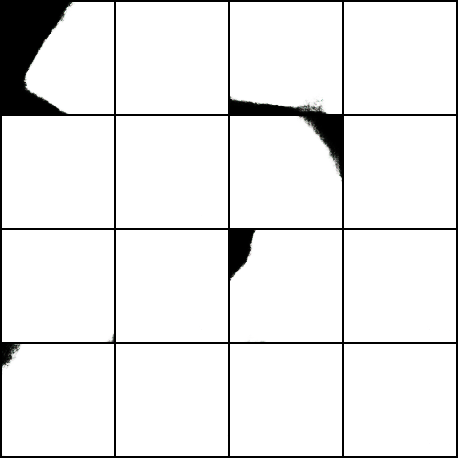

In [9]:
from pathlib import Path
from IPython.display import Image, display

latest = sorted(Path('runs/gan/samples').glob('epoch_*.png'))[-1]
display(Image(filename=str(latest)))

## 6. Sample the trained generator into a synthetic pool

Check the class counts printed by `prepare_ddsm.py` above (step 4) and set these to roughly balance or oversample the minority class -- CBIS-DDSM is not perfectly balanced between benign and malignant, unlike the defaults below which assume a rough 600/600 split.

In [10]:
!python generate_synthetic.py --checkpoint runs/gan/checkpoints/ddsm_acgan_final.pt --out-dir data/synthetic --n-benign 600 --n-malignant 600

wrote 600 synthetic benign images to data/synthetic/benign
wrote 600 synthetic malignant images to data/synthetic/malignant


## 7. CNN-AD — detection CNN trained on real ROIs only (baseline)

In [11]:
!python train_classifier.py --manifest data/manifest.csv --mode ad --out-dir runs/cnn_ad --epochs 25 --batch-size 16 --lr 1e-3

device: cuda  mode: ad
train: 2864 real (actual-data only)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:03<00:00, 168MB/s]
params: 14,747,650 total, 32,962 trainable
epoch 1/25  loss=0.6781  train_acc=58.69%
epoch 2/25  loss=0.6726  train_acc=58.97%
epoch 3/25  loss=0.6699  train_acc=58.87%
epoch 4/25  loss=0.6663  train_acc=58.90%
epoch 5/25  loss=0.6649  train_acc=59.18%
epoch 6/25  loss=0.6630  train_acc=59.46%
epoch 7/25  loss=0.6613  train_acc=59.60%
epoch 8/25  loss=0.6580  train_acc=60.51%
epoch 9/25  loss=0.6536  train_acc=60.54%
epoch 10/25  loss=0.6485  train_acc=61.38%
epoch 11/25  loss=0.6503  train_acc=61.03%
epoch 12/25  loss=0.6450  train_acc=61.87%
epoch 13/25  loss=0.6428  train_acc=61.07%
epoch 14/25  loss=0.6380  train_acc=61.35%
epoch 15/25  loss=0.6351  train_acc=62.47%
epoch 16/25  loss=0.6350  train_acc=62.36%
epoch 17/25  loss=0.6318  train_acc=63.09%
epoch 18/25

## 8. CNN-SA — same CNN, trained on real + synthetic ROIs

In [12]:
!python train_classifier.py --manifest data/manifest.csv --mode sa --synthetic-dir data/synthetic --out-dir runs/cnn_sa --epochs 25 --batch-size 16 --lr 1e-3

device: cuda  mode: sa
train: 2864 real + 1200 synthetic = 4064
params: 14,747,650 total, 32,962 trainable
epoch 1/25  loss=0.6585  train_acc=58.56%
epoch 2/25  loss=0.6435  train_acc=59.84%
epoch 3/25  loss=0.6404  train_acc=60.14%
epoch 4/25  loss=0.6335  train_acc=60.56%
epoch 5/25  loss=0.6313  train_acc=61.27%
epoch 6/25  loss=0.6270  train_acc=61.54%
epoch 7/25  loss=0.6238  train_acc=60.95%
epoch 8/25  loss=0.6236  train_acc=61.74%
epoch 9/25  loss=0.6195  train_acc=62.06%
epoch 10/25  loss=0.6165  train_acc=62.50%
epoch 11/25  loss=0.6160  train_acc=62.38%
epoch 12/25  loss=0.6131  train_acc=62.60%
epoch 13/25  loss=0.6086  train_acc=62.87%
epoch 14/25  loss=0.6112  train_acc=62.87%
epoch 15/25  loss=0.6002  train_acc=62.89%
epoch 16/25  loss=0.5978  train_acc=63.48%
epoch 17/25  loss=0.5991  train_acc=63.24%
epoch 18/25  loss=0.5951  train_acc=64.15%
epoch 19/25  loss=0.5922  train_acc=64.22%
epoch 20/25  loss=0.5910  train_acc=64.37%
epoch 21/25  loss=0.5931  train_acc=64.39%

## 9. Compare CNN-AD vs CNN-SA

In [13]:
print('=== CNN-AD (real ROIs only) ===')
print(Path('runs/cnn_ad/metrics.txt').read_text())
print()
print('=== CNN-SA (real + synthetic) ===')
print(Path('runs/cnn_sa/metrics.txt').read_text())

=== CNN-AD (real ROIs only) ===
class        precision    recall        f1   support  specificity
benign            0.61      0.84      0.70       428         0.15
malignant         0.38      0.15      0.21       276         0.84
macro avg         0.49      0.49      0.46       704
weighted avg      0.52      0.57      0.51       704

accuracy: 56.96%

=== CNN-SA (real + synthetic) ===
class        precision    recall        f1   support  specificity
benign            0.64      0.44      0.52       428         0.62
malignant         0.41      0.62      0.50       276         0.44
macro avg         0.53      0.53      0.51       704
weighted avg      0.55      0.51      0.51       704

accuracy: 50.85%


CNN-AD confusion matrix


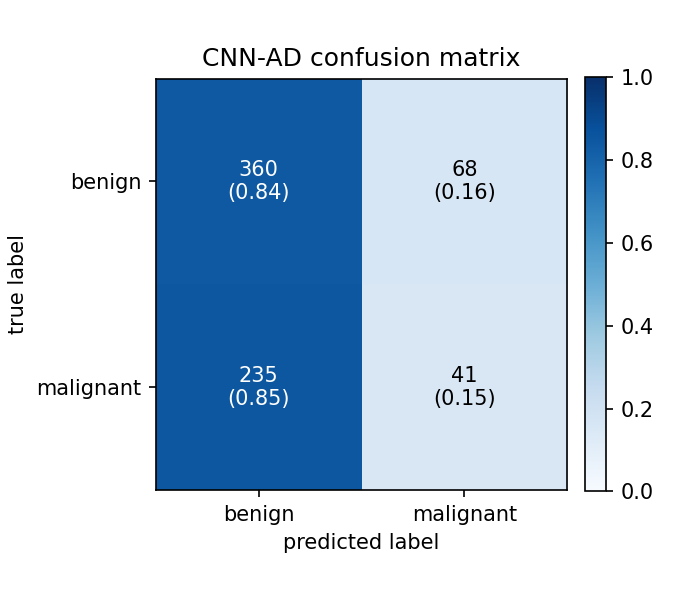

CNN-SA confusion matrix


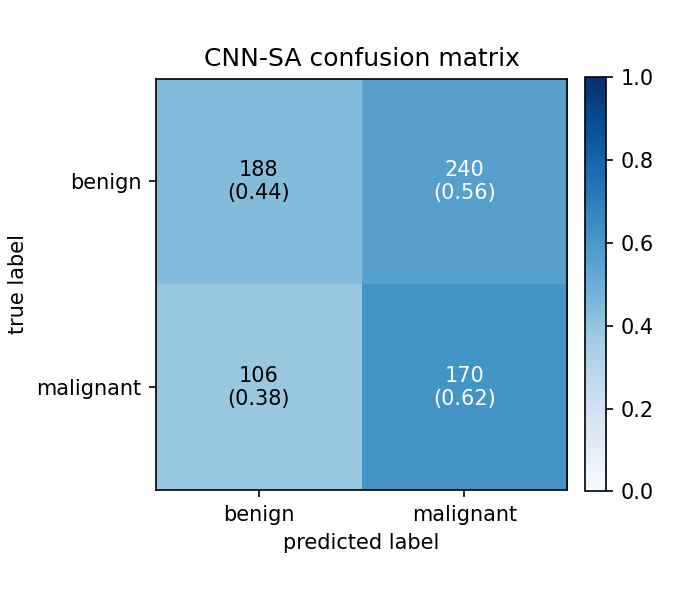

PCA of penultimate-layer features (real vs. synthetic)


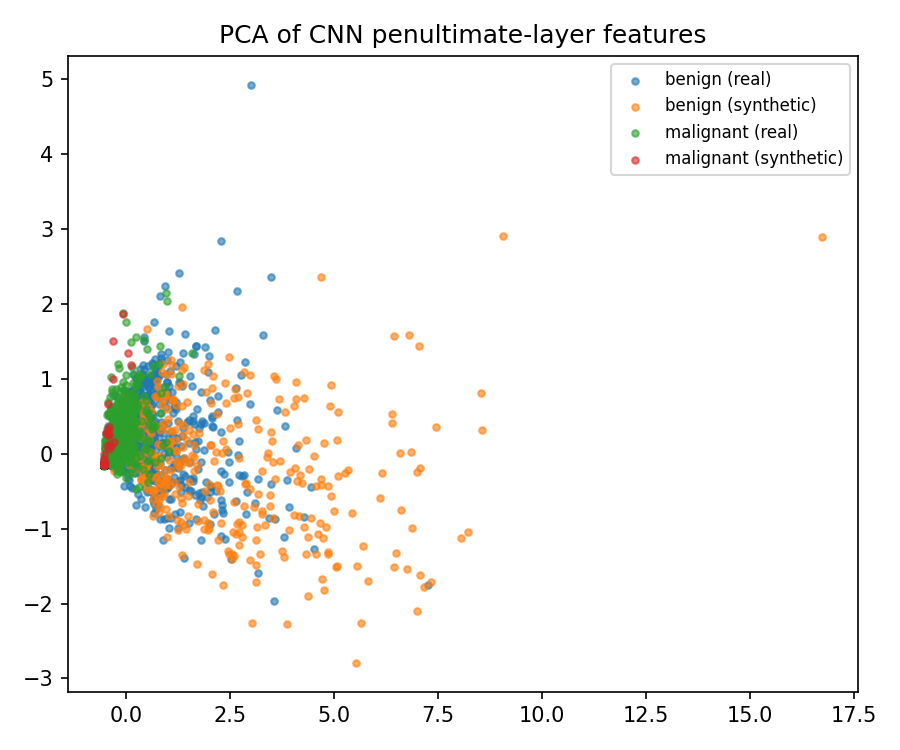

In [14]:
from IPython.display import Image, display

print('CNN-AD confusion matrix')
display(Image(filename='runs/cnn_ad/confusion_matrix.png'))
print('CNN-SA confusion matrix')
display(Image(filename='runs/cnn_sa/confusion_matrix.png'))
print('PCA of penultimate-layer features (real vs. synthetic)')
display(Image(filename='runs/cnn_sa/pca.png'))

## 10. (Optional) Persist results to Google Drive

In [15]:
!mkdir -p /content/drive/MyDrive/ddsm_acgan_runs
!cp -r runs /content/drive/MyDrive/ddsm_acgan_runs/
!cp data/manifest.csv /content/drive/MyDrive/ddsm_acgan_runs/